# Fan Atomic NoPE Hidden-State Diagnostics

This notebook visualizes how the `fan-recurrent` Atomic + NoPE checkpoint changes its SLOT hidden states across recurrence loops on long swap samples. It is intentionally analysis-only: it loads an existing checkpoint and dataset split, then produces four diagnostic plots.

Default target: latest `runs/original/fan-atomic-nope-curr2to10-seed0__*/checkpoint.pt` on `data/boundary_sweep/boundary_11_19.jsonl`.

In [1]:
from __future__ import annotations

import json
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

ROOT = Path.cwd()
for candidate in (ROOT, *ROOT.parents):
    if (candidate / "src" / "original" / "model.py").is_file():
        ROOT = candidate
        break
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.original.experiment import make_loader, resolve_device, trajectory_targets_for_loops
from src.original.model import FanRecurrentTransformer, OriginalModelConfig, build_model

plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

CHECKPOINT = None
CHECKPOINT_GLOB = "runs/original/fan-atomic-nope-curr2to10-seed0__*/checkpoint.pt"
DATA_DIR = ROOT / "data" / "boundary_sweep"
SPLIT = "boundary_11_19"
DEVICE = "mps"
BATCH_SIZE = 128
MAX_SAMPLES = None
NUM_LOOPS = 20
SWAPS_PER_LOOP = 1.0
MAX_PCA_POINTS = 25_000
RANDOM_SEED = 0


## Load Checkpoint And Data

In [2]:
def latest_checkpoint() -> Path:
    if CHECKPOINT is not None:
        path = Path(CHECKPOINT)
        return path if path.is_absolute() else ROOT / path
    matches = sorted(
        ROOT.glob(CHECKPOINT_GLOB),
        key=lambda path: path.stat().st_mtime,
        reverse=True,
    )
    if not matches:
        raise FileNotFoundError(f"No checkpoint matched {CHECKPOINT_GLOB!r}")
    return matches[0]


checkpoint_path = latest_checkpoint()
payload = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
config = OriginalModelConfig(**payload["config"])
model = build_model(config)
if not isinstance(model, FanRecurrentTransformer):
    raise TypeError(f"Expected FanRecurrentTransformer, got {type(model).__name__}")
model.load_state_dict(payload["model_state"], strict=True)
device = resolve_device(DEVICE)
model.to(device).eval()

split_path = DATA_DIR / f"{SPLIT}.jsonl"
loader = make_loader(
    split_path,
    config.architecture,
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=0,
    max_samples=MAX_SAMPLES,
    slot_first=False,
    swaps_per_loop=None,
    input_format=config.fan_input_format,
)

print(json.dumps({
    "checkpoint": str(checkpoint_path.relative_to(ROOT)),
    "split": str(split_path.relative_to(ROOT)),
    "architecture": config.architecture,
    "fan_input_format": config.fan_input_format,
    "position_encoding": config.position_encoding,
    "num_loops_visualized": NUM_LOOPS,
    "device": str(device),
}, indent=2))


{
  "checkpoint": "runs/original/fan-atomic-nope-curr2to10-seed0__20260816-135135/checkpoint.pt",
  "split": "data/boundary_sweep/boundary_11_19.jsonl",
  "architecture": "fan-recurrent",
  "fan_input_format": "atomic",
  "position_encoding": "none",
  "num_loops_visualized": 20,
  "device": "mps"
}


## Collect Loop Hidden States

The model classifier reads `final_norm(hidden)` at SLOT positions. The collected hidden states below use that same normalized SLOT view, not a mean over all input tokens.

In [3]:
def move_batch(batch: dict[str, torch.Tensor], device: torch.device) -> dict[str, torch.Tensor]:
    return {key: value.to(device) if torch.is_tensor(value) else value for key, value in batch.items()}


def gather_slots(hidden: torch.Tensor, slot_positions: torch.Tensor) -> torch.Tensor:
    indices = slot_positions.unsqueeze(-1).expand(-1, -1, hidden.shape[-1])
    return hidden.gather(1, indices)


@torch.inference_mode()
def collect_artifacts(model: FanRecurrentTransformer, loader, device: torch.device, num_loops: int):
    slot_hidden_batches = []
    logits_batches = []
    labels_batches = []
    trajectory_batches = []
    n_swaps_batches = []

    for batch_cpu in loader:
        batch = move_batch(batch_cpu, device)
        loop_logits, hidden_states = model.forward_all_loops(
            batch["input_ids"],
            batch["attn_mask"],
            batch["slot_pos"],
            num_loops=num_loops,
            return_hidden_states=True,
        )
        normalized_slots = []
        mask = batch["attn_mask"].unsqueeze(-1).to(dtype=hidden_states[0].dtype)
        for hidden in hidden_states:
            normalized = model.final_norm(hidden) * mask
            normalized_slots.append(gather_slots(normalized, batch["slot_pos"]))
        slot_hidden_batches.append(torch.stack(normalized_slots, dim=1).cpu())
        logits_batches.append(loop_logits.cpu())
        labels_batches.append(batch_cpu["labels"].cpu())
        trajectory_batches.append(batch_cpu["trajectory_labels"].cpu())
        n_swaps_batches.append(batch_cpu["n_swaps"].cpu())

    return {
        "slot_hidden": torch.cat(slot_hidden_batches, dim=0),
        "logits": torch.cat(logits_batches, dim=0),
        "labels": torch.cat(labels_batches, dim=0),
        "trajectory_labels": torch.cat(trajectory_batches, dim=0),
        "n_swaps": torch.cat(n_swaps_batches, dim=0),
    }


artifacts = collect_artifacts(model, loader, device, NUM_LOOPS)
for key, value in artifacts.items():
    print(key, tuple(value.shape))


slot_hidden (900, 20, 5, 128)
logits (900, 20, 5, 5)
labels (900, 5)
trajectory_labels (900, 19, 5)
n_swaps (900,)


## Shared Metrics

In [4]:
slot_hidden = artifacts["slot_hidden"]
logits = artifacts["logits"]
labels = artifacts["labels"]
trajectory_labels = artifacts["trajectory_labels"]
n_swaps = artifacts["n_swaps"]

predictions = logits.argmax(dim=-1)
targets, target_indices = trajectory_targets_for_loops(
    trajectory_labels,
    n_swaps,
    NUM_LOOPS,
    swaps_per_loop=SWAPS_PER_LOOP,
)
valid = targets != -100
correct = (predictions == targets) & valid

slot_accuracy_by_loop = correct.sum(dim=(0, 2)) / valid.sum(dim=(0, 2)).clamp_min(1)
exact_by_loop = (correct | ~valid).all(dim=2).float().mean(dim=0)
mean_target_swap = (target_indices + 1).float().mean(dim=0)

matched_loop_index = torch.clamp(n_swaps, max=NUM_LOOPS) - 1
sample_index = torch.arange(labels.shape[0])
matched_predictions = predictions[sample_index, matched_loop_index]
matched_success = (matched_predictions == labels).all(dim=1)

print(json.dumps({
    "n_samples": int(labels.shape[0]),
    "swap_min": int(n_swaps.min()),
    "swap_max": int(n_swaps.max()),
    "length_matched_exact": float(matched_success.float().mean()),
    "length_matched_successes": int(matched_success.sum()),
}, indent=2))


{
  "n_samples": 900,
  "swap_min": 11,
  "swap_max": 19,
  "length_matched_exact": 0.9155555367469788,
  "length_matched_successes": 824
}


## 1. Loop-Aligned Readout Accuracy

This checks whether loop `k` reads out the symbolic state after approximately `k * swaps_per_loop` swaps. For Atomic + NoPE with `swaps_per_loop=1`, this is the direct Fan-aligned diagnostic.

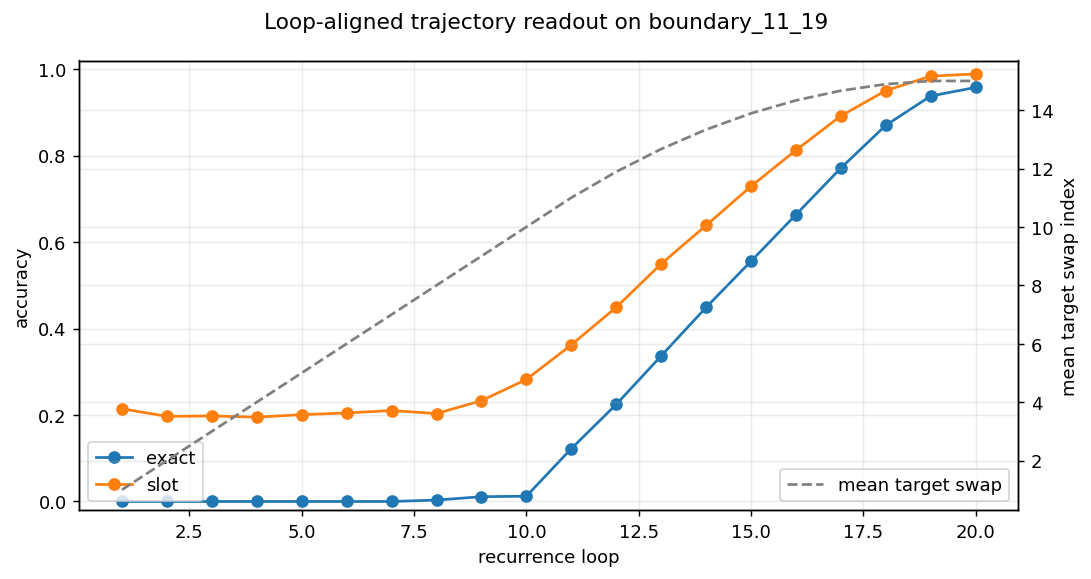

In [5]:
loops = np.arange(1, NUM_LOOPS + 1)

fig, ax1 = plt.subplots(figsize=(8.5, 4.5))
ax1.plot(loops, exact_by_loop.numpy(), marker="o", label="exact")
ax1.plot(loops, slot_accuracy_by_loop.numpy(), marker="o", label="slot")
ax1.set_xlabel("recurrence loop")
ax1.set_ylabel("accuracy")
ax1.set_ylim(-0.02, 1.02)
ax1.legend(loc="lower left")

ax2 = ax1.twinx()
ax2.plot(loops, mean_target_swap.numpy(), color="tab:gray", linestyle="--", label="mean target swap")
ax2.set_ylabel("mean target swap index")
ax2.legend(loc="lower right")

fig.suptitle(f"Loop-aligned trajectory readout on {SPLIT}")
fig.tight_layout()
plt.show()


## 2. Update Norm, Entropy, And Margin

If recurrence keeps doing useful work, update norms and classifier confidence should show a structured trend. Collapse toward zero suggests early convergence; large updates with falling accuracy suggests hidden-state drift.

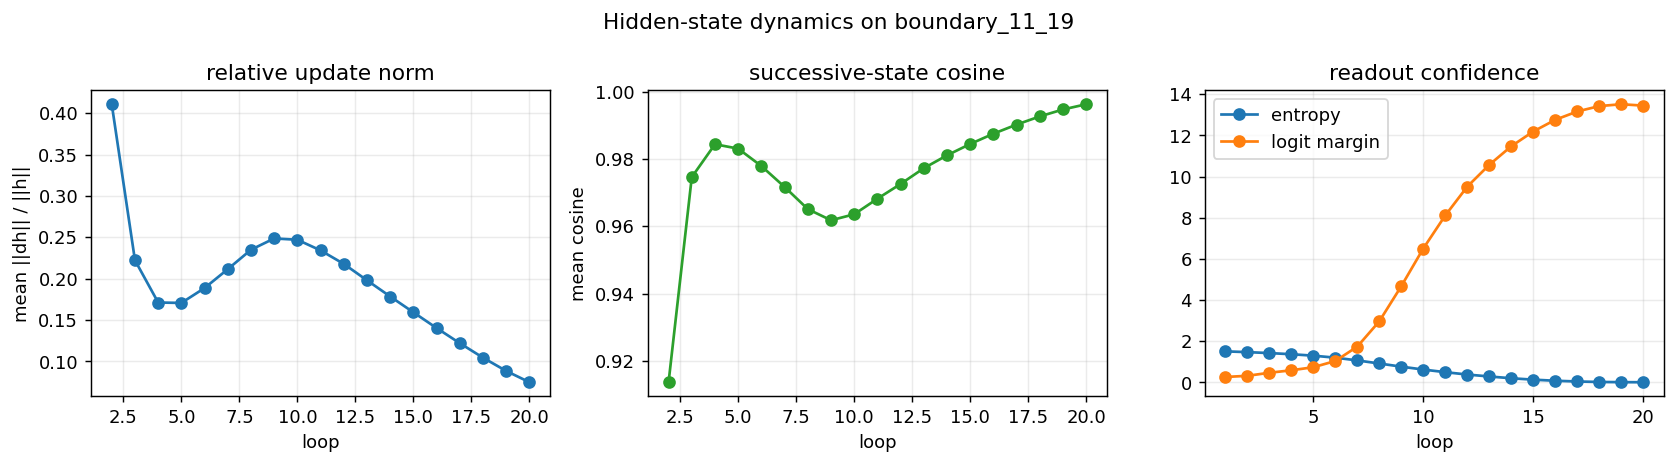

In [6]:
delta = slot_hidden[:, 1:] - slot_hidden[:, :-1]
relative_l2 = delta.norm(dim=-1) / slot_hidden[:, :-1].norm(dim=-1).clamp_min(1e-8)
cosine = torch.nn.functional.cosine_similarity(slot_hidden[:, 1:], slot_hidden[:, :-1], dim=-1)

probs = torch.softmax(logits, dim=-1)
entropy = -(probs.clamp_min(1e-9).log() * probs).sum(dim=-1)
top2 = logits.topk(2, dim=-1).values
margin = top2[..., 0] - top2[..., 1]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
axes[0].plot(loops[1:], relative_l2.mean(dim=(0, 2)).numpy(), marker="o")
axes[0].set_title("relative update norm")
axes[0].set_xlabel("loop")
axes[0].set_ylabel("mean ||dh|| / ||h||")

axes[1].plot(loops[1:], cosine.mean(dim=(0, 2)).numpy(), marker="o", color="tab:green")
axes[1].set_title("successive-state cosine")
axes[1].set_xlabel("loop")
axes[1].set_ylabel("mean cosine")

axes[2].plot(loops, entropy.mean(dim=(0, 2)).numpy(), marker="o", label="entropy")
axes[2].plot(loops, margin.mean(dim=(0, 2)).numpy(), marker="o", label="logit margin")
axes[2].set_title("readout confidence")
axes[2].set_xlabel("loop")
axes[2].legend()

fig.suptitle(f"Hidden-state dynamics on {SPLIT}")
fig.tight_layout()
plt.show()


## 3. SLOT Hidden PCA

PCA is fit on normalized SLOT hidden vectors from the selected long-swap split. The scatter shows a downsampled set of slot states; the black line tracks the loop centroid.

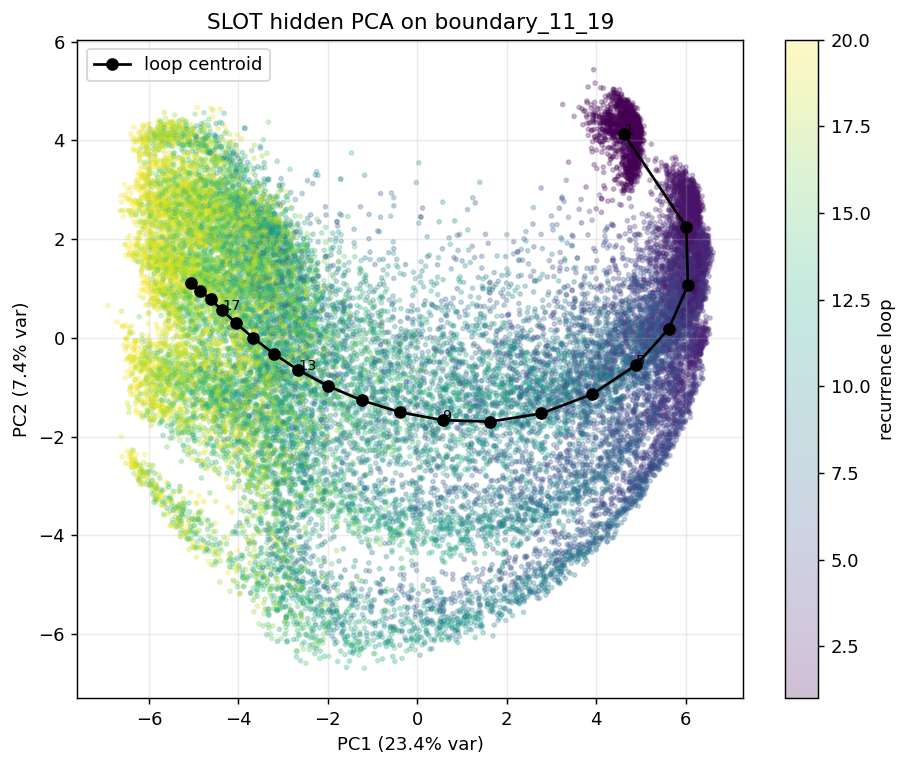

In [7]:
def fit_pca_torch(x: torch.Tensor, n_components: int = 2):
    x = x.float()
    mean = x.mean(dim=0, keepdim=True)
    centered = x - mean
    _, singular_values, vh = torch.linalg.svd(centered, full_matrices=False)
    components = vh[:n_components]
    explained = singular_values.square() / singular_values.square().sum().clamp_min(1e-12)
    return mean, components, explained[:n_components]


def pca_transform(x: torch.Tensor, mean: torch.Tensor, components: torch.Tensor) -> torch.Tensor:
    return (x.float() - mean) @ components.T


flat_hidden = slot_hidden.reshape(-1, slot_hidden.shape[-1])
pca_mean, pca_components, pca_explained = fit_pca_torch(flat_hidden, n_components=2)
coords = pca_transform(flat_hidden, pca_mean, pca_components).reshape(*slot_hidden.shape[:-1], 2)

rng = np.random.default_rng(RANDOM_SEED)
n_points = flat_hidden.shape[0]
selected = rng.choice(n_points, size=min(MAX_PCA_POINTS, n_points), replace=False)
coords_flat = coords.reshape(-1, 2).numpy()
loop_flat = np.tile(np.repeat(loops, slot_hidden.shape[2]), slot_hidden.shape[0])

centroids = coords.mean(dim=(0, 2)).numpy()

fig, ax = plt.subplots(figsize=(7.2, 6.0))
scatter = ax.scatter(
    coords_flat[selected, 0],
    coords_flat[selected, 1],
    c=loop_flat[selected],
    s=5,
    alpha=0.25,
    cmap="viridis",
)
ax.plot(centroids[:, 0], centroids[:, 1], color="black", marker="o", linewidth=1.5, label="loop centroid")
for index in range(0, NUM_LOOPS, max(1, NUM_LOOPS // 5)):
    ax.annotate(str(index + 1), centroids[index], fontsize=8)
ax.set_xlabel(f"PC1 ({float(pca_explained[0]) * 100:.1f}% var)")
ax.set_ylabel(f"PC2 ({float(pca_explained[1]) * 100:.1f}% var)")
ax.set_title(f"SLOT hidden PCA on {SPLIT}")
ax.legend(loc="best")
fig.colorbar(scatter, ax=ax, label="recurrence loop")
fig.tight_layout()
plt.show()


## 4. Success vs Failure PCA Trajectories

A sample is marked successful if its readout at loop `n_swaps` exactly matches the final state. The plot compares the average PCA trajectory of successful and failed samples.

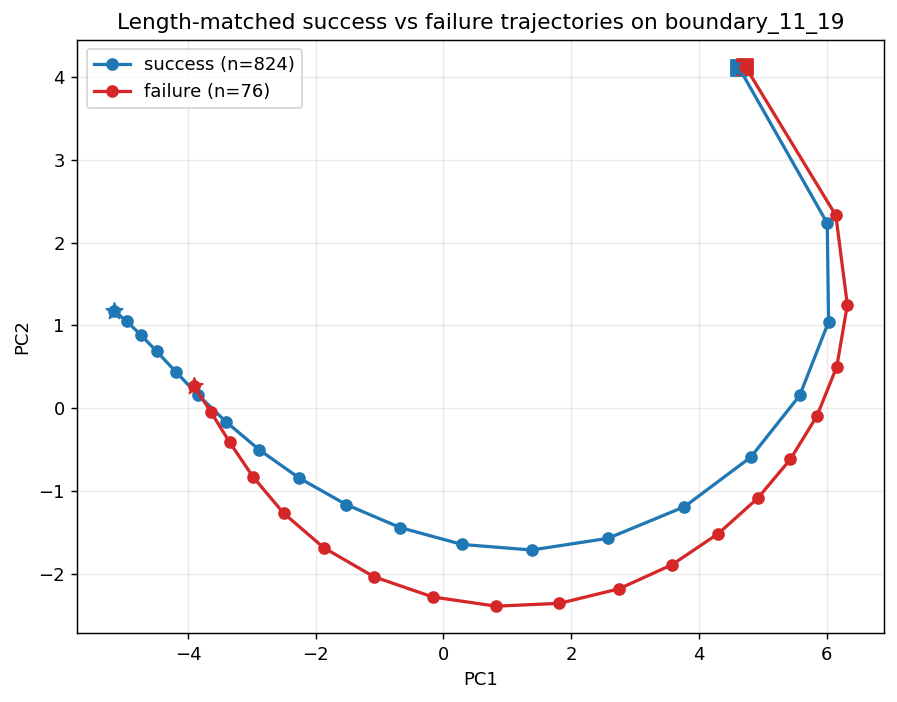

[
  {
    "n_swaps": 11,
    "samples": 100,
    "length_matched_exact": 1.0
  },
  {
    "n_swaps": 12,
    "samples": 100,
    "length_matched_exact": 1.0
  },
  {
    "n_swaps": 13,
    "samples": 100,
    "length_matched_exact": 1.0
  },
  {
    "n_swaps": 14,
    "samples": 100,
    "length_matched_exact": 0.9900000095367432
  },
  {
    "n_swaps": 15,
    "samples": 100,
    "length_matched_exact": 0.9800000190734863
  },
  {
    "n_swaps": 16,
    "samples": 100,
    "length_matched_exact": 0.9300000071525574
  },
  {
    "n_swaps": 17,
    "samples": 100,
    "length_matched_exact": 0.8999999761581421
  },
  {
    "n_swaps": 18,
    "samples": 100,
    "length_matched_exact": 0.8500000238418579
  },
  {
    "n_swaps": 19,
    "samples": 100,
    "length_matched_exact": 0.5899999737739563
  }
]


In [8]:
def plot_group_centroid(ax, group_mask: torch.Tensor, label: str, color: str):
    count = int(group_mask.sum())
    if count == 0:
        print(f"Skipping {label}: no samples")
        return
    group_coords = coords[group_mask].mean(dim=(0, 2)).numpy()
    ax.plot(group_coords[:, 0], group_coords[:, 1], marker="o", linewidth=1.8, label=f"{label} (n={count})", color=color)
    ax.scatter(group_coords[0, 0], group_coords[0, 1], color=color, s=70, marker="s")
    ax.scatter(group_coords[-1, 0], group_coords[-1, 1], color=color, s=90, marker="*")


fig, ax = plt.subplots(figsize=(7.0, 5.5))
plot_group_centroid(ax, matched_success, "success", "tab:blue")
plot_group_centroid(ax, ~matched_success, "failure", "tab:red")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title(f"Length-matched success vs failure trajectories on {SPLIT}")
ax.legend(loc="best")
fig.tight_layout()
plt.show()

summary_by_swaps = []
for swap_count in sorted(n_swaps.unique().tolist()):
    mask = n_swaps == swap_count
    summary_by_swaps.append({
        "n_swaps": int(swap_count),
        "samples": int(mask.sum()),
        "length_matched_exact": float(matched_success[mask].float().mean()),
    })
print(json.dumps(summary_by_swaps, indent=2))
